# 🔮 Predicciones Interactivas

## Usa tus modelos entrenados para predecir sentimientos

En este notebook aprenderás a:
1. Cargar modelos ya entrenados
2. Hacer predicciones con nuevos textos
3. Comparar predicciones de diferentes modelos
4. Interpretar la confianza de las predicciones

In [1]:
import sys
from pathlib import Path

# Agregar el directorio del proyecto al path
NOTEBOOK_DIR = Path.cwd()
PROJECT_DIR = NOTEBOOK_DIR.parent
sys.path.insert(0, str(PROJECT_DIR))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

import tensorflow as tf
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing.sequence import pad_sequences
import joblib
import pickle

import config
from src import text_preprocessing

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (14, 6)
%matplotlib inline

print(f"✅ TensorFlow: {tf.__version__}")
print(f"✅ Librerías importadas")

✅ Configuración cargada exitosamente
📁 Directorio base: d:\work\repos-deep-learning\sentiment-analysis
🗂️  Dataset: IMDB
🧠 Vocabulario: top 10000 palabras
📏 Longitud máxima de secuencia: 300 palabras
✅ TensorFlow: 2.20.0
✅ Librerías importadas


## 📁 Configurar Rutas

In [2]:
MODELS_DIR = PROJECT_DIR / 'models'
REPORTS_DIR = PROJECT_DIR / 'reports'

# Rutas de modelos
MODEL_LSTM = MODELS_DIR / 'lstm_sentiment_model.keras'
TOKENIZER_FILE = MODELS_DIR / 'tokenizer.pkl'
MODEL_SVM = MODELS_DIR / 'tfidf_svm_model.pkl'
VECTORIZER_FILE = MODELS_DIR / 'tfidf_vectorizer.pkl'

print("📁 Rutas configuradas:")
print(f"   • Modelos: {MODELS_DIR}")
print(f"   • Reportes: {REPORTS_DIR}")

📁 Rutas configuradas:
   • Modelos: d:\work\repos-deep-learning\sentiment-analysis\models
   • Reportes: d:\work\repos-deep-learning\sentiment-analysis\reports


## 🔍 Verificar Modelos Disponibles

In [3]:
print("="*70)
print("🔍 MODELOS DISPONIBLES")
print("="*70)

models_status = {
    'LSTM Model': MODEL_LSTM.exists(),
    'LSTM Tokenizer': TOKENIZER_FILE.exists(),
    'SVM Model': MODEL_SVM.exists(),
    'TF-IDF Vectorizer': VECTORIZER_FILE.exists()
}

for model_name, exists in models_status.items():
    status = "✅" if exists else "❌"
    print(f"{status} {model_name}")

if not all(models_status.values()):
    print("\n⚠️  Algunos modelos faltan. Ejecuta primero:")
    print("   python main.py  (para entrenar todos los modelos)")
    print("   O:")
    print("   Notebook 05 (para entrenar solo LSTM)")
else:
    print("\n✅ Todos los modelos están listos para usar")

🔍 MODELOS DISPONIBLES
✅ LSTM Model
✅ LSTM Tokenizer
✅ SVM Model
✅ TF-IDF Vectorizer

✅ Todos los modelos están listos para usar


## 📥 Cargar Modelo LSTM

In [4]:
print("="*70)
print("📥 CARGANDO MODELO LSTM")
print("="*70)

# Cargar modelo
print("\n🧠 Cargando modelo LSTM...")
lstm_model = load_model(str(MODEL_LSTM))
print(f"   ✅ Modelo cargado: {MODEL_LSTM.name}")
print(f"   Tamaño: {MODEL_LSTM.stat().st_size / 1024 / 1024:.2f} MB")

# Cargar tokenizer
print("\n📝 Cargando tokenizer...")
with open(TOKENIZER_FILE, 'rb') as f:
    tokenizer = pickle.load(f)
print(f"   ✅ Tokenizer cargado")
print(f"   Vocabulario: {len(tokenizer.word_index):,} palabras")

# Mostrar arquitectura
print("\n📊 Arquitectura del modelo:")
lstm_model.summary()

📥 CARGANDO MODELO LSTM

🧠 Cargando modelo LSTM...
   ✅ Modelo cargado: lstm_sentiment_model.keras
   Tamaño: 7.76 MB

📝 Cargando tokenizer...
   ✅ Tokenizer cargado
   Vocabulario: 9,998 palabras

📊 Arquitectura del modelo:


Model: "LSTM_Sentiment"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 300, 64)        │       640,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 64)             │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,025,413 (7.73 MB)

 Trainable params: 675,137 (2.58 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 1,350,276 (5.15 MB)

## 📥 Cargar Modelo SVM (opcional)

In [5]:
if MODEL_SVM.exists() and VECTORIZER_FILE.exists():
    print("="*70)
    print("📥 CARGANDO MODELO SVM")
    print("="*70)
    
    # Cargar SVM
    print("\n🤖 Cargando modelo SVM...")
    svm_model = joblib.load(MODEL_SVM)
    print(f"   ✅ Modelo SVM cargado")
    
    # Cargar vectorizador
    print("\n📊 Cargando vectorizador TF-IDF...")
    tfidf_vectorizer = joblib.load(VECTORIZER_FILE)
    print(f"   ✅ Vectorizador cargado")
    print(f"   Features: {len(tfidf_vectorizer.get_feature_names_out())} palabras")
    
    svm_available = True
else:
    print("⚠️  Modelo SVM no disponible (solo usaremos LSTM)")
    svm_available = False

📥 CARGANDO MODELO SVM

🤖 Cargando modelo SVM...
   ✅ Modelo SVM cargado

📊 Cargando vectorizador TF-IDF...
   ✅ Vectorizador cargado
   Features: 5000 palabras


## 🔮 Funciones de Predicción

In [6]:
def predict_lstm(text, model, tokenizer, max_length=300):
    """
    Predice el sentimiento de un texto usando LSTM.
    
    Args:
        text (str): Texto a analizar
        model: Modelo LSTM cargado
        tokenizer: Tokenizer de Keras
        max_length: Longitud máxima de secuencia
    
    Returns:
        tuple: (probabilidad, etiqueta, confianza)
    """
    # Tokenizar y convertir a secuencia
    sequence = tokenizer.texts_to_sequences([text])
    padded = pad_sequences(sequence, maxlen=max_length, padding='post', truncating='post')
    
    # Predecir
    probability = model.predict(padded, verbose=0)[0][0]
    
    # Interpretar resultado
    if probability > 0.5:
        label = "POSITIVO 😊"
        confidence = probability
    else:
        label = "NEGATIVO 😞"
        confidence = 1 - probability
    
    return probability, label, confidence


def predict_svm(text, model, vectorizer):
    """
    Predice el sentimiento de un texto usando SVM.
    
    Args:
        text (str): Texto a analizar
        model: Modelo SVM cargado
        vectorizer: Vectorizador TF-IDF
    
    Returns:
        tuple: (predicción, etiqueta, confianza)
    """
    # Preprocesar texto
    text_processed = text_preprocessing.preprocess_text(text)
    
    # Vectorizar
    text_vectorized = vectorizer.transform([text_processed])
    
    # Predecir
    prediction = model.predict(text_vectorized)[0]
    
    # Obtener probabilidad (si el modelo lo soporta)
    try:
        proba = model.predict_proba(text_vectorized)[0]
        confidence = proba[1] if prediction == 1 else proba[0]
    except:
        # Si no tiene predict_proba, usar decision_function
        decision = model.decision_function(text_vectorized)[0]
        confidence = abs(decision) / 2  # Normalizar aproximadamente
    
    # Interpretar resultado
    label = "POSITIVO 😊" if prediction == 1 else "NEGATIVO 😞"
    
    return prediction, label, confidence


print("✅ Funciones de predicción definidas")

✅ Funciones de predicción definidas


## 🧪 Ejemplos de Prueba

In [7]:
# Reviews de películas de ejemplo
test_reviews = [
    # POSITIVAS
    "This movie is absolutely brilliant! A masterpiece of cinema.",
    "One of the best films I have ever seen. Outstanding performances!",
    "Incredible storyline and amazing cinematography. Highly recommended!",
    "I loved every minute of it! The acting was superb.",
    
    # NEGATIVAS
    "Terrible movie. Complete waste of time and money.",
    "Boring plot, bad screenplay. One of the worst films ever.",
    "Completely disappointing. The director should be ashamed.",
    "Awful acting and terrible story. Don't watch this.",
    
    # NEUTRAS/MIXTAS
    "It was okay. Not great but not terrible either.",
    "Some good moments but overall average. Decent acting though.",
]

print(f"📝 {len(test_reviews)} reviews de prueba cargadas")

📝 10 reviews de prueba cargadas


## 🔮 Predicciones con LSTM

In [8]:
print("="*70)
print("🔮 PREDICCIONES CON LSTM")
print("="*70)

results_lstm = []

for i, review in enumerate(test_reviews, 1):
    prob, label, conf = predict_lstm(review, lstm_model, tokenizer)
    
    results_lstm.append({
        'review': review,
        'probability': prob,
        'label': label,
        'confidence': conf
    })
    
    print(f"\n{i}. {label} (confianza: {conf:.2%})")
    print(f"   \"{review}\"")
    print(f"   Probabilidad: {prob:.4f}")

# Convertir a DataFrame
df_lstm = pd.DataFrame(results_lstm)
print(f"\n✅ {len(results_lstm)} predicciones completadas")

🔮 PREDICCIONES CON LSTM

1. POSITIVO 😊 (confianza: 65.46%)
   "This movie is absolutely brilliant! A masterpiece of cinema."
   Probabilidad: 0.6546

2. POSITIVO 😊 (confianza: 53.79%)
   "One of the best films I have ever seen. Outstanding performances!"
   Probabilidad: 0.5379

3. NEGATIVO 😞 (confianza: 55.00%)
   "Incredible storyline and amazing cinematography. Highly recommended!"
   Probabilidad: 0.4500

4. NEGATIVO 😞 (confianza: 57.58%)
   "I loved every minute of it! The acting was superb."
   Probabilidad: 0.4242

5. NEGATIVO 😞 (confianza: 65.14%)
   "Terrible movie. Complete waste of time and money."
   Probabilidad: 0.3486

6. NEGATIVO 😞 (confianza: 71.28%)
   "Boring plot, bad screenplay. One of the worst films ever."
   Probabilidad: 0.2872

7. NEGATIVO 😞 (confianza: 63.92%)
   "Completely disappointing. The director should be ashamed."
   Probabilidad: 0.3608

8. POSITIVO 😊 (confianza: 68.69%)
   "Awful acting and terrible story. Don't watch this."
   Probabilidad: 0.6869


## 🤖 Predicciones con SVM (si está disponible)

In [9]:
if svm_available:
    print("="*70)
    print("🤖 PREDICCIONES CON SVM")
    print("="*70)
    
    results_svm = []
    
    for i, review in enumerate(test_reviews, 1):
        pred, label, conf = predict_svm(review, svm_model, tfidf_vectorizer)
        
        results_svm.append({
            'review': review,
            'prediction': pred,
            'label': label,
            'confidence': conf
        })
        
        print(f"\n{i}. {label} (confianza: {conf:.2%})")
        print(f"   \"{review}\"")
    
    df_svm = pd.DataFrame(results_svm)
    print(f"\n✅ {len(results_svm)} predicciones completadas")
else:
    print("⚠️  SVM no disponible, saltando...")

🤖 PREDICCIONES CON SVM

1. NEGATIVO 😞 (confianza: 85.75%)
   "This movie is absolutely brilliant! A masterpiece of cinema."

2. POSITIVO 😊 (confianza: 1.48%)
   "One of the best films I have ever seen. Outstanding performances!"

3. POSITIVO 😊 (confianza: 7.50%)
   "Incredible storyline and amazing cinematography. Highly recommended!"

4. NEGATIVO 😞 (confianza: 31.40%)
   "I loved every minute of it! The acting was superb."

5. POSITIVO 😊 (confianza: 40.07%)
   "Terrible movie. Complete waste of time and money."

6. POSITIVO 😊 (confianza: 28.59%)
   "Boring plot, bad screenplay. One of the worst films ever."

7. NEGATIVO 😞 (confianza: 46.36%)
   "Completely disappointing. The director should be ashamed."

8. NEGATIVO 😞 (confianza: 28.74%)
   "Awful acting and terrible story. Don't watch this."

9. NEGATIVO 😞 (confianza: 4.80%)
   "It was okay. Not great but not terrible either."

10. POSITIVO 😊 (confianza: 82.23%)
   "Some good moments but overall average. Decent acting though."

✅ 10 

## 📊 Comparación de Modelos

In [10]:
if svm_available:
    print("="*70)
    print("📊 COMPARACIÓN LSTM vs SVM")
    print("="*70)
    
    comparison = pd.DataFrame({
        'Review': [r[:50] + '...' if len(r) > 50 else r for r in test_reviews],
        'LSTM': df_lstm['label'].values,
        'LSTM Conf': df_lstm['confidence'].values,
        'SVM': df_svm['label'].values,
        'SVM Conf': df_svm['confidence'].values,
    })
    
    # Marcar desacuerdos
    comparison['Coinciden'] = comparison['LSTM'] == comparison['SVM']
    
    print("\n📋 Tabla de comparación:")
    print(comparison.to_string(index=False))
    
    # Estadísticas
    agreement = (comparison['Coinciden'].sum() / len(comparison)) * 100
    print(f"\n📊 Estadísticas:")
    print(f"   • Acuerdo entre modelos: {agreement:.1f}%")
    print(f"   • Desacuerdos: {(~comparison['Coinciden']).sum()} de {len(comparison)}")
    
    if agreement < 100:
        print(f"\n⚠️  Casos de desacuerdo:")
        disagreements = comparison[~comparison['Coinciden']]
        for idx, row in disagreements.iterrows():
            print(f"\n   {idx + 1}. {row['Review']}")
            print(f"      LSTM: {row['LSTM']} ({row['LSTM Conf']:.1%})")
            print(f"      SVM:  {row['SVM']} ({row['SVM Conf']:.1%})")

📊 COMPARACIÓN LSTM vs SVM

📋 Tabla de comparación:
                                               Review       LSTM  LSTM Conf        SVM  SVM Conf  Coinciden
This movie is absolutely brilliant! A masterpiece ... POSITIVO 😊   0.654647 NEGATIVO 😞  0.857533      False
One of the best films I have ever seen. Outstandin... POSITIVO 😊   0.537926 POSITIVO 😊  0.014815       True
Incredible storyline and amazing cinematography. H... NEGATIVO 😞   0.550002 POSITIVO 😊  0.075042      False
   I loved every minute of it! The acting was superb. NEGATIVO 😞   0.575760 NEGATIVO 😞  0.314003       True
    Terrible movie. Complete waste of time and money. NEGATIVO 😞   0.651447 POSITIVO 😊  0.400729      False
Boring plot, bad screenplay. One of the worst film... NEGATIVO 😞   0.712841 POSITIVO 😊  0.285894      False
Completely disappointing. The director should be a... NEGATIVO 😞   0.639212 NEGATIVO 😞  0.463553       True
   Awful acting and terrible story. Don't watch this. POSITIVO 😊   0.686900 NEGATIVO 

## 📊 Visualización de Confianza

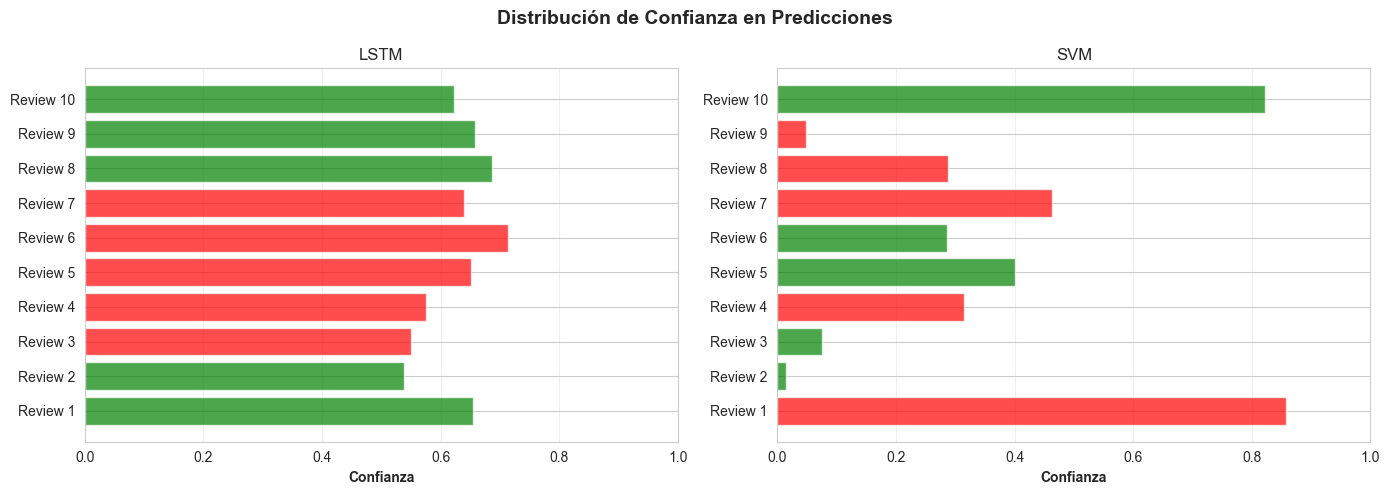

✅ Visualización guardada


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Distribución de Confianza en Predicciones', fontsize=14, fontweight='bold')

# LSTM
axes[0].barh(range(len(df_lstm)), df_lstm['confidence'], 
             color=['green' if 'POSITIVO' in label else 'red' for label in df_lstm['label']],
             alpha=0.7)
axes[0].set_yticks(range(len(df_lstm)))
axes[0].set_yticklabels([f"Review {i+1}" for i in range(len(df_lstm))])
axes[0].set_xlabel('Confianza', fontweight='bold')
axes[0].set_title('LSTM')
axes[0].set_xlim(0, 1)
axes[0].grid(True, alpha=0.3, axis='x')

# SVM (si está disponible)
if svm_available:
    axes[1].barh(range(len(df_svm)), df_svm['confidence'],
                 color=['green' if 'POSITIVO' in label else 'red' for label in df_svm['label']],
                 alpha=0.7)
    axes[1].set_yticks(range(len(df_svm)))
    axes[1].set_yticklabels([f"Review {i+1}" for i in range(len(df_svm))])
    axes[1].set_xlabel('Confianza', fontweight='bold')
    axes[1].set_title('SVM')
    axes[1].set_xlim(0, 1)
    axes[1].grid(True, alpha=0.3, axis='x')
else:
    axes[1].text(0.5, 0.5, 'SVM no disponible', 
                ha='center', va='center', fontsize=12)
    axes[1].set_xticks([])
    axes[1].set_yticks([])

plt.tight_layout()
plt.savefig(REPORTS_DIR / 'prediction_confidence.png', dpi=300, bbox_inches='tight')
plt.show()

print("✅ Visualización guardada")

## 🎯 Prueba con Tus Propios Textos

¡Ahora prueba con tus propias reviews!

In [12]:
def analyze_sentiment(text):
    """
    Analiza el sentimiento de un texto con todos los modelos disponibles.
    """
    print("="*70)
    print("🔮 ANÁLISIS DE SENTIMIENTO")
    print("="*70)
    print(f"\n📝 Texto: \"{text}\"")
    print("\n" + "-"*70)
    
    # LSTM
    prob, label, conf = predict_lstm(text, lstm_model, tokenizer)
    print(f"\n🧠 LSTM:")
    print(f"   • Predicción: {label}")
    print(f"   • Confianza: {conf:.2%}")
    print(f"   • Probabilidad raw: {prob:.4f}")
    
    # SVM
    if svm_available:
        pred, label_svm, conf_svm = predict_svm(text, svm_model, tfidf_vectorizer)
        print(f"\n🤖 SVM:")
        print(f"   • Predicción: {label_svm}")
        print(f"   • Confianza: {conf_svm:.2%}")
        
        # Comparar
        if label == label_svm:
            print(f"\n✅ Ambos modelos coinciden: {label}")
        else:
            print(f"\n⚠️  Los modelos NO coinciden:")
            print(f"   LSTM: {label} ({conf:.1%})")
            print(f"   SVM:  {label_svm} ({conf_svm:.1%})")
    
    print("\n" + "="*70)

# Ejemplos para probar
print("💡 Ejemplos de uso:\n")
print("analyze_sentiment('This movie was fantastic! I loved it!')")
print("analyze_sentiment('Worst film I have ever seen. Terrible.')")
print("analyze_sentiment('Your own review here...')")

💡 Ejemplos de uso:

analyze_sentiment('This movie was fantastic! I loved it!')
analyze_sentiment('Worst film I have ever seen. Terrible.')
analyze_sentiment('Your own review here...')


In [13]:
# 🎯 PRUEBA AQUÍ CON TUS PROPIOS TEXTOS

# Ejemplo 1: Review positiva
analyze_sentiment("This movie was absolutely amazing! Best film of the year.")

🔮 ANÁLISIS DE SENTIMIENTO

📝 Texto: "This movie was absolutely amazing! Best film of the year."

----------------------------------------------------------------------

🧠 LSTM:
   • Predicción: POSITIVO 😊
   • Confianza: 65.33%
   • Probabilidad raw: 0.6533

🤖 SVM:
   • Predicción: NEGATIVO 😞
   • Confianza: 36.09%

⚠️  Los modelos NO coinciden:
   LSTM: POSITIVO 😊 (65.3%)
   SVM:  NEGATIVO 😞 (36.1%)



In [14]:
# Ejemplo 2: Review negativa
analyze_sentiment("The movie destroys every moment with absurd dialogue and terrible acting.")

🔮 ANÁLISIS DE SENTIMIENTO

📝 Texto: "The movie destroys every moment with absurd dialogue and terrible acting."

----------------------------------------------------------------------

🧠 LSTM:
   • Predicción: NEGATIVO 😞
   • Confianza: 65.72%
   • Probabilidad raw: 0.3428

🤖 SVM:
   • Predicción: NEGATIVO 😞
   • Confianza: 13.19%

✅ Ambos modelos coinciden: NEGATIVO 😞



In [15]:
# Ejemplo 3: Review mixta
analyze_sentiment("The movie had some good moments, but overall it was disappointing.")

🔮 ANÁLISIS DE SENTIMIENTO

📝 Texto: "The movie had some good moments, but overall it was disappointing."

----------------------------------------------------------------------

🧠 LSTM:
   • Predicción: POSITIVO 😊
   • Confianza: 80.75%
   • Probabilidad raw: 0.8075

🤖 SVM:
   • Predicción: NEGATIVO 😞
   • Confianza: 7.97%

⚠️  Los modelos NO coinciden:
   LSTM: POSITIVO 😊 (80.7%)
   SVM:  NEGATIVO 😞 (8.0%)



In [17]:
# 🎨 TU TURNO: Escribe tu propia review aquí
analyze_sentiment("""This film is a tedious mess, plagued by weak writing and lifeless performances.""")

🔮 ANÁLISIS DE SENTIMIENTO

📝 Texto: "This film is a tedious mess, plagued by weak writing and lifeless performances."

----------------------------------------------------------------------

🧠 LSTM:
   • Predicción: NEGATIVO 😞
   • Confianza: 58.21%
   • Probabilidad raw: 0.4179

🤖 SVM:
   • Predicción: POSITIVO 😊
   • Confianza: 30.06%

⚠️  Los modelos NO coinciden:
   LSTM: NEGATIVO 😞 (58.2%)
   SVM:  POSITIVO 😊 (30.1%)



## 📊 Análisis de Múltiples Textos

In [18]:
# Función para analizar múltiples textos y generar informe
def batch_analysis(texts):
    """
    Analiza múltiples textos y genera un informe.
    """
    results = []
    
    for text in texts:
        prob, label, conf = predict_lstm(text, lstm_model, tokenizer)
        results.append({
            'text': text[:60] + '...' if len(text) > 60 else text,
            'sentiment': label,
            'confidence': conf,
            'probability': prob
        })
    
    df = pd.DataFrame(results)
    
    # Estadísticas
    print("="*70)
    print("📊 ANÁLISIS BATCH")
    print("="*70)
    print(f"\nTotal de textos analizados: {len(texts)}")
    
    # Distribución de sentimientos
    sentiment_counts = df['sentiment'].value_counts()
    print("\n📈 Distribución de sentimientos:")
    for sentiment, count in sentiment_counts.items():
        percentage = (count / len(df)) * 100
        print(f"   • {sentiment}: {count} ({percentage:.1f}%)")
    
    # Confianza promedio
    avg_confidence = df['confidence'].mean()
    print(f"\n💪 Confianza promedio: {avg_confidence:.2%}")
    
    # Textos con baja confianza
    low_confidence = df[df['confidence'] < 0.7]
    if len(low_confidence) > 0:
        print(f"\n⚠️  {len(low_confidence)} textos con baja confianza (< 70%):")
        for idx, row in low_confidence.iterrows():
            print(f"   {idx+1}. {row['text']} [{row['sentiment']}, {row['confidence']:.1%}]")
    
    return df

# Ejemplo
my_reviews = [
    "Excellent movie with great acting!",
    "Boring and predictable storyline.",
    "The cinematography was stunning.",
    "Waste of money, terrible film.",
    "It was okay, nothing special."
]

batch_results = batch_analysis(my_reviews)
print("\n📋 Resultados detallados:")
print(batch_results.to_string(index=False))

📊 ANÁLISIS BATCH

Total de textos analizados: 5

📈 Distribución de sentimientos:
   • POSITIVO 😊: 3 (60.0%)
   • NEGATIVO 😞: 2 (40.0%)

💪 Confianza promedio: 58.56%

⚠️  5 textos con baja confianza (< 70%):
   1. Excellent movie with great acting! [POSITIVO 😊, 53.2%]
   2. Boring and predictable storyline. [NEGATIVO 😞, 51.3%]
   3. The cinematography was stunning. [POSITIVO 😊, 51.8%]
   4. Waste of money, terrible film. [NEGATIVO 😞, 66.7%]
   5. It was okay, nothing special. [POSITIVO 😊, 69.8%]

📋 Resultados detallados:
                              text  sentiment  confidence  probability
Excellent movie with great acting! POSITIVO 😊    0.531628     0.531628
 Boring and predictable storyline. NEGATIVO 😞    0.512604     0.487396
  The cinematography was stunning. POSITIVO 😊    0.518482     0.518482
    Waste of money, terrible film. NEGATIVO 😞    0.666886     0.333114
     It was okay, nothing special. POSITIVO 😊    0.698467     0.698467


## 🎓 Resumen y Próximos Pasos

### ✅ Lo que aprendiste:

1. **Cargar modelos entrenados** - Reutilizar modelos sin reentrenar
2. **Hacer predicciones** - Usar LSTM y SVM para análisis de sentimientos
3. **Interpretar confianza** - Entender qué tan seguro está el modelo
4. **Comparar modelos** - Ver diferencias entre LSTM y SVM
5. **Análisis batch** - Procesar múltiples textos eficientemente

### 🚀 Próximos pasos:

1. **Crear una web app** con Streamlit para predicciones interactivas
2. **Exportar el modelo** para producción
3. **Fine-tuning** con tus propios datos
4. **Probar con otros idiomas** (español, francés, etc.)
5. **Análisis de aspectos** - Qué específicamente gusta/disgusta

### 📚 Recursos adicionales:

- Ver `src/predictor.py` para clases de predicción completas
- Revisar `main.py demo` para ejemplos del pipeline
- Explorar `web/app.py` si quieres crear una interfaz web

## 💾 Guardar Resultados

In [19]:
# Guardar predicciones de ejemplo
output_file = REPORTS_DIR / 'sample_predictions.csv'
df_lstm.to_csv(output_file, index=False)
print(f"✅ Predicciones guardadas en: {output_file.name}")

if svm_available:
    comparison_file = REPORTS_DIR / 'model_comparison.csv'
    comparison.to_csv(comparison_file, index=False)
    print(f"✅ Comparación guardada en: {comparison_file.name}")

print("\n🎉 ¡Notebook completado! Ahora puedes experimentar con tus propios textos.")

✅ Predicciones guardadas en: sample_predictions.csv
✅ Comparación guardada en: model_comparison.csv

🎉 ¡Notebook completado! Ahora puedes experimentar con tus propios textos.
